In [13]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import torch

import qwen_embeddings
import conv_neural
import recurrent_neural_integrated

VOCAB_SIZE = 151936
EMB_DIM = 1536
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

random_seed = 42

torch.manual_seed(random_seed)
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed(random_seed)
else:
    device = torch.device("cpu")

In [17]:
with open('../data/session_29_results.json', 'r', encoding='utf8') as f:
    raw_dict = json.load(f)

user_posts = {}
for post in raw_dict['posts']:
    user = post['author_id']
    if user not in user_posts:
        user_posts[user] = []

    user_posts[user].append([post['text'], post['created_at']])

test_data = []
for user in raw_dict['users']:
    user_id = user['user_id']
    test_data.append([user_id, user['is_bot'], user['description'], user['location'], user_posts[user_id], user['z_score']])

In [19]:
embedding, tokenizer = qwen_embeddings.load_embedding_model(
    vocab_size=VOCAB_SIZE,
    emb_dim=EMB_DIM,
    embeddings_filename='../out/embeddings_qwen.pth',
    tokenizer_name=MODEL_NAME
)
embedding.to(device)

Embedding(151936, 1536)

In [21]:
temp_cnn = conv_neural.conv_neural_network(
    embedding_dim=EMB_DIM,
    num_filters_list=3*[EMB_DIM]
)

model_rnn = recurrent_neural_integrated.recurrent_neural_network(
    cnn_dim=3*EMB_DIM,
    hidden_dim=2*EMB_DIM,
    cnn=temp_cnn
    ).to(device)
model_rnn.load_state_dict(torch.load('../out/saved_models/integrated_rnn_qwen_1.pt', weights_only=True))

<All keys matched successfully>

In [27]:
import re
import emoji

def replace_unicode(text):
    regex1 = re.sub('\u2019', "'", text)
    demojified_text = emoji.demojize(regex1)
    regex2 = re.sub(':', '', demojified_text)
    regex3 = re.sub('https://t.co/twitter_link', 'link', regex2)
    return regex3

In [29]:
stats_dict, user_export = recurrent_neural_integrated.test_rnn(test_data, embedding, model_rnn, device, tokenizer, replace_unicode, thresh=0.81, save_output=True)

Preprocessing data...


  0%|          | 0/389 [00:00<?, ?it/s]

Preprocessing finished



  0%|          | 0/389 [00:00<?, ?it/s]

  0%|          | 0/389 [00:00<?, ?it/s]

isbot-conf: 0.6724653500132263
nobot-conf: 0.12104730586279694
tp:8
fn:8
fp:3
tn:370
Maximum confidence prediction on real user: 0.9261677861213684
90th percentile prediction on real user: 0.37158934473991395
Minimum prediction for a bot user: 0.03145772963762283
Maximum prediction for a bot user: 0.9964855909347534


In [129]:
stats_dict2, user_export2 = recurrent_neural_integrated.test_rnn(test_data, embedding, model_rnn, device, tokenizer, replace_unicode, thresh=0.5, save_output=True)

Preprocessing data...


  0%|          | 0/389 [00:00<?, ?it/s]

Preprocessing finished



  0%|          | 0/389 [00:00<?, ?it/s]

  0%|          | 0/389 [00:00<?, ?it/s]

isbot-conf: 0.6724653500132263
nobot-conf: 0.12104730586279694
tp:12
fn:4
fp:24
tn:349
Maximum confidence prediction on real user: 0.9261677861213684
90th percentile prediction on real user: 0.37158934473991395
Minimum prediction for a bot user: 0.03145772963762283
Maximum prediction for a bot user: 0.9964855909347534


In [133]:
24/(24+349)

0.064343163538874

In [31]:
print(stats_dict)

{'TP': 8, 'FP': 3, 'TN': 370, 'FN': 8, '90th_percentile': 0.37158934473991395, '95th_percentile': 0.5446132540702819, '99th_percentile': 0.7755687499046319, 'maximum_prediction_human': 0.9261677861213684, 'average_confidence_bot': 0.6724653500132263, 'average_confidence_human': 0.12104730586279694}


In [33]:
print(user_export[0])

['827fe3fb-d94b-b9b3-817b-89852ac84a7a', False, 0.042376480996608734, False]


In [35]:
not_bot_points = np.array([user[2] for user in user_export if not user[1]])
is_bot_points = np.array([user[2] for user in user_export if user[1]])

In [85]:
def plot_multi_hist(positive_points, negative_points, min_val=0, max_val=1, num=20, save=None, width=12, height=4):
    bins = np.linspace(min_val, max_val, num)
    plt.figure(figsize=(width, height))
    plt.hist(positive_points, bins, alpha=0.5, label='Bot Users', color='r')
    plt.hist(negative_points, bins, alpha=0.5, label='Human Users', color='g')

    plt.legend(loc='upper right')
    plt.xlabel('Model confidence value')
    plt.ylabel('Number of users')
    plt.tight_layout()

    if save:
        plt.savefig(f'../out/{save}.png')

    plt.show()

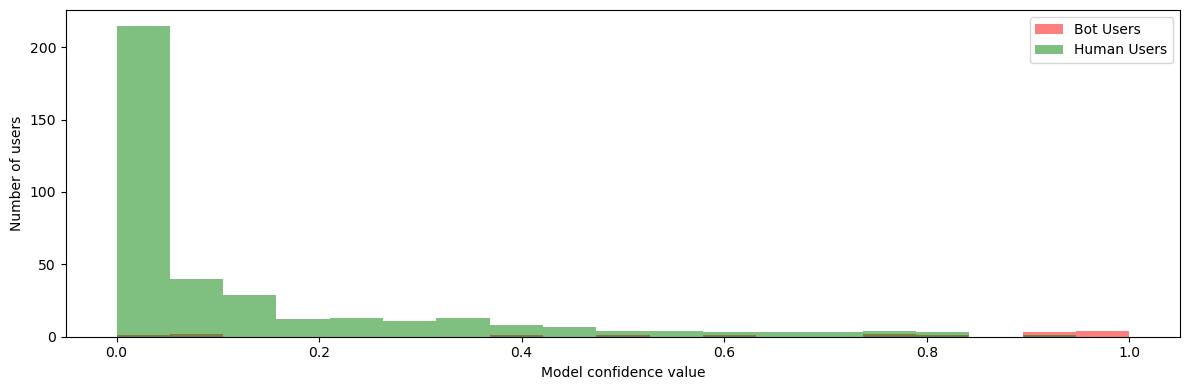

In [87]:
plot_multi_hist(is_bot_points, not_bot_points, save='best_model')

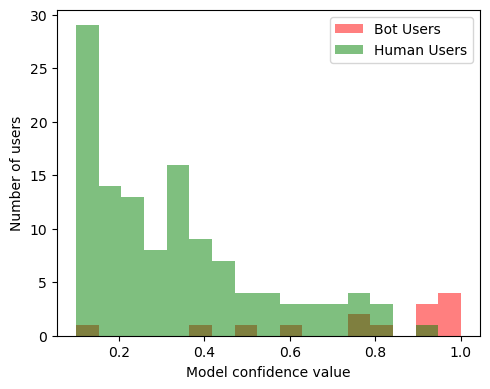

In [89]:
plot_multi_hist(is_bot_points, not_bot_points, min_val=0.1, num=18, save='best_model_trunc', width=5)

In [125]:
def plot_multi_hist_2(positive_points, negative_points, min_val=0, max_val=1, num=20, save=None, width=16, height=5):
    bins = np.linspace(min_val, max_val, num)
    f, (a0, a1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [3, 1]}, figsize=(width, height))
    a0.hist(positive_points, bins, alpha=0.5, label='Bot Users', color='r')
    a0.hist(negative_points, bins, alpha=0.5, label='Human Users', color='g')
    
    a0.set_xlabel('Model confidence value')
    a0.set_ylabel('Number of users')
    a0.legend(loc='upper right')

    bins2 = np.linspace(0.1, 1, 18)
    a1.hist(positive_points, bins2, alpha=0.5, label='Bot Users', color='r')
    a1.hist(negative_points, bins2, alpha=0.5, label='Human Users', color='g')

    a1.legend(loc='upper right')
    a1.set_xlabel('Model confidence value')
    a1.set_title('Zoom on confidence > 0.1')
    f.tight_layout()

    if save:
        f.savefig(f'../out/{save}.png')

    plt.show()

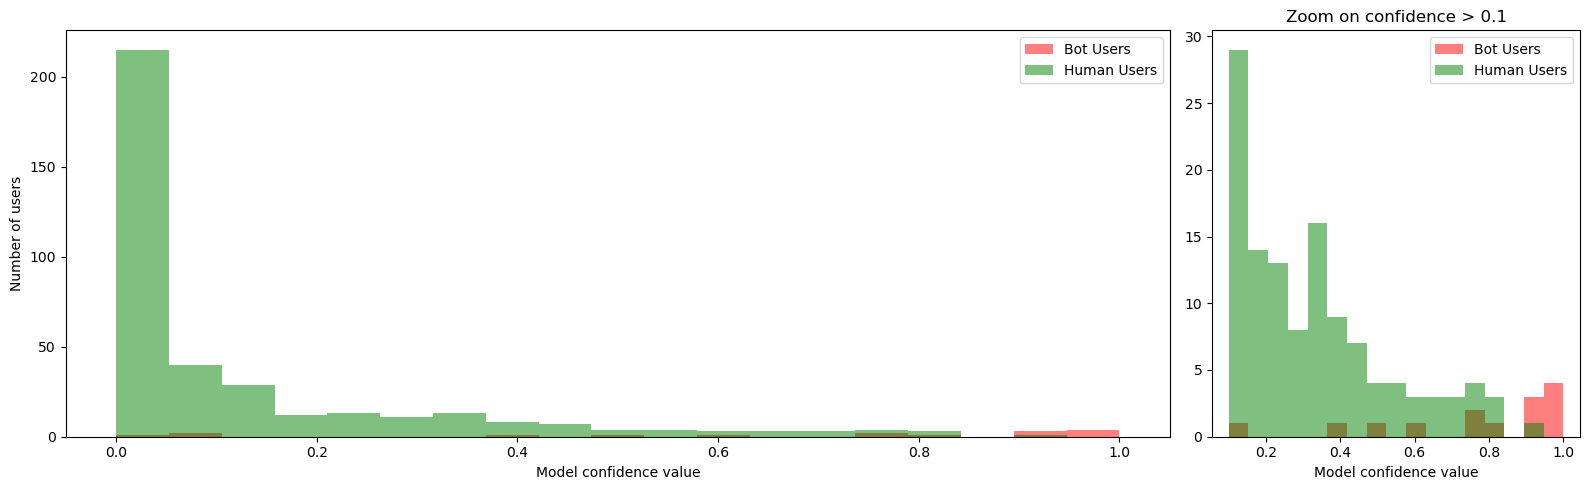

In [127]:
plot_multi_hist_2(is_bot_points, not_bot_points, save='best_model_comp')